# Welcome to my Linear Classifier

In [1]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


#Choose device (CUDA, MPS or CPU)
device_type = {'cuda': 'Nvidia GPU', 'mps': 'Apple Silicon GPU', 'cpu': 'whatever random computer you decided to train models on'}

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

print(f">Now using: {device_type[device.type]}")

#MNIST preperation
transform = transforms.Compose([transforms.ToTensor()])

root = "./data"
raw_dir = os.path.join(root, "MNIST", "raw")
needed = [
    "train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz",
]
have_all = all(os.path.exists(os.path.join(raw_dir, f)) for f in needed)
print(">MNIST data satisfied" if have_all else ">MNIST data missing, destroy /data in directory if download doesn't start")

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
seed = 2138
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(seed))
num_classes = 10
input_dim = 28*28
print(f">Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")

>Now using: Apple Silicon GPU
>MNIST data satisfied
>Train samples: 54000, Validation samples: 6000, Test samples: 10000


## Introduction

This Python program trains a linear classifier to recognize handwritten digits from the **MNIST** dataset. Each input image consists of 28×28 grayscale pixels. The model contains 10 output neurons, one for each possible digit (0–9).

Each neuron computes a weighted sum of the 784 pixel values, producing a score (logit) for its corresponding digit. The predicted digit is determined by selecting the neuron with the highest score.

For example, given an input image, like this one below:

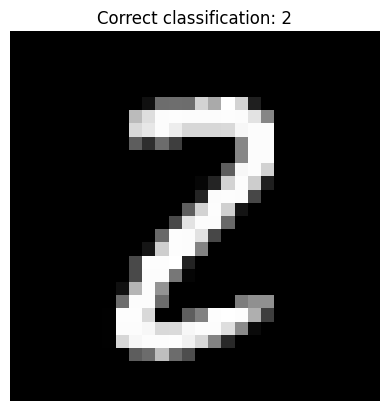

In [2]:
idx = 2138  
x, y = test_dataset[idx]
plt.imshow(x.squeeze(0), cmap="gray")
plt.title(f"Correct classification: {y}")
plt.axis("off")
plt.show()

If the neuron corresponding to the digit “2” produces the highest score, the model correctly classifies the image as a 2; however, as you can see, confusing this digit with a 7 would be an easy mistake for a poorly trained model. Seen below is the code for the linear classifier itself:

In [3]:
class LinearClassifier(nn.Module):
    #Define a Pytorch model
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes) #Basic equation shape

    #How the model handles inputs
    def forward(self, x):
        x = x.flatten(1)  #Flattens images to vectors
        return self.fc(x) #Produces the logits from matrix multiplication with the complete equation

The model will be trained using the Pytroch library, specifically using stochastic gradient descent with cross-entropy loss and L2 regularization (weight decay). Cross-entropy penalizes incorrect predictions, particularly those made with high confidence. The introduction of L2 regularization discourages excessively large weights to improve generalization, and as a result bringing more bias to decrease variance. 

## The Math

### The Classifier

The math for how the model works, comes out to a linear equation that is interpreted as a probability. The digits 0 to 9 yield 10 distinct **classes**. Each input image has pixels (or dimensions) 28 × 28, which results in 784 total **input features** after flattening. So essentially a flattened vector representing pixel values will be fed in and the predicted digit based on the input image will come out.

The logits for this linear classifier can be expressed as:
$$
z_k = b_k + \sum_{i=1}^{784} W_{k,i}\, x_i
$$

where:

- $x_i$ represents the $i$-th pixel value of the flattened input image
- $W_{k,i}$ is the weight associated with pixel $i$ for class $k$
- $b_k$ is the bias term for class $k$
- $z_k$ is the resulting logit (pre-softmax), after which argmax will provide de facto classification for class $k$

Or equivalently, this expression can be written in vector form as

$$
z_k = b_k + w_k^\top x
$$

where $x \in \mathbb{R}^{784}$ is the flattened input vector and $w_k \in \mathbb{R}^{784}$ is the weight vector corresponding to class $k$. This is the single equation that captures the essence of the model. In that vector, $z_k$, will be 10 values that are transformed into 10 possible choices, from which the most probable output is chosen, the classification.

### The Training

Cross-entropy loss is strict and that's thanks to the negative log applied to softmax. It is calculated like this for a single input with logits $z$ and true class label $y$, the loss is:

$$
\mathcal{L}_{CE} = - \log \left( \frac{e^{z_y}}{\sum_{k=1}^{K} e^{z_k}} \right)
$$

For a batch of $N$ samples:

$$
\mathcal{L}_{CE} = -\frac{1}{N} \sum_{n=1}^{N} \log \left( \frac{e^{z_{y_n}}}{\sum_{k=1}^{K} e^{z_k}} \right)
$$

L2 regularization, like mentioned before, is added to discourage excessively large weight magnitudes and improve generalization:

$$
\mathcal{L}_{L2} = \lambda \| W \|_F^2
$$

where $W \in \mathbb{R}^{10 \times 784}$ contains all model weights and

$$
\| W \|_F^2 = \sum_{i,j} W_{i,j}^2
$$

is the squared Frobenius norm of the weight matrix.

The full objective function becomes:

$$
\mathcal{L}(W,b) = \mathcal{L}_{CE}(W,b) + \lambda \| W \|_F^2
$$

This objective is minimized using Stochastic Gradient Descent (SGD) with learning rate $\eta$, where the weight update rule is:

$$
W \leftarrow W - \eta \nabla_W \mathcal{L}(W,b)
$$

With the information from **backpropagation** that identifies the source of loss, SGD can make the necessary adjustments to shift weights in the hopes of minimizing loss.

Expanding the gradient gives:

$$
W \leftarrow W - \eta \left( \nabla_W \mathcal{L}_{CE} + 2\lambda W \right)
$$

In practice, PyTorch implements weight decay directly in the optimizer step rather than explicitly adding the penalty term to the loss.

## Hyper-Parameters

To properly train the model, beyond the foundational parameters of this model (bias vector $b$ and weight matrix $W$) are the hyperparameters that the model doesn't acquire from the data but are tuned by engineers. These hyperparameters are how models are trained effeciently so getting high accuracy from the model's predictions takes minutes, not hours.

Below are the hyperparameters with base values:

In [4]:
#Hyperparameters collated in one varible
base_config = {
    'num_epochs': 10,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'batch_size': 128
}


#Grid sets ready to slot in
LR_set = [3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1]
L2_set = [0.0, 1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]
batch_set = [16, 32, 64, 128, 256, 512]

These base values for the hyperparameters are relatively arbitrary and bound to change, since they will be tested against other possible values which I have here in grid sets. The grid sets are made up of heuristic values, loosely tied to their respective purposes:

- **Learning rate $\eta$**  
  Controls the step size of each optimizer update thus large steps can overshoot and small steps can undershoot. 

- **Weight decay/L2 regularization $\lambda$**  
  As mentioned earlier, adds a penalty proportional to the squared magnitude of the weights ($\|W\|^2$). 

- **Batch size**  
  This represents the number of training examples used to compute one gradient update. Smaller batches make gradient updates slower but better for generalization, large batches give smoother gradients but introduce more dependence on the learning rate. 

- **Number of epochs**  
  The number of epochs represents how many times the training loop, the core of the program, is going to run before the program calls it quits and the model that comes out the other end is what's going to be tested. I've decided to focus on 10 epochs since it shouldn't take many rounds to get high accuracy.

## The Training Loop

As seen below, is the core of the program. Here, is where every topic previously discussed will finally be implemented to realize the linear classifier. 

In [5]:

#Plotting stuff
def plot_loss_acc(history, run_name="Run"):

    #Used in the future: history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    epochs = history["epoch"]

    #Loss on left axis
    fig, ax1 = plt.subplots(figsize=(7, 4.5))
    loss_train_line, = ax1.plot(epochs, history["train_loss"], label="Train Loss", linestyle="--")
    loss_val_line, = ax1.plot(epochs, history["val_loss"], label="Val Loss", linestyle="--")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")

    #Accuracy on right axis
    ax2 = ax1.twinx()
    acc_train_line, = ax2.plot(epochs, history["train_acc"], label="Train Acc")
    acc_val_line, = ax2.plot(epochs, history["val_acc"], label="Val Acc")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_ylim(0, 100)

    #Full graph
    plt.title(f"{run_name}: Loss & Accuracy vs Epoch")
    lines = [loss_train_line, loss_val_line, acc_train_line, acc_val_line]
    ax1.legend(lines, [l.get_label() for l in lines], loc="center right")
    plt.tight_layout()
    plt.show()

#This function is dual purpose for training/evaluation epochs
def _run_epoch(model, loader, criterion, device, optimizer=None):

    is_train = optimizer is not None
    model.train(is_train)

    loss_sum = 0.0
    correct = 0
    total = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            batch_size = labels.size(0) #Get the batch part of the tuple
            loss_sum += loss.item() * batch_size
            total += batch_size
            correct += (outputs.argmax(dim=1) == labels).sum().item()

    avg_loss = loss_sum / total
    acc = 100.0 * correct / total
    return avg_loss, acc

#The main function
def trainLoopAndPlot(run_config, run_name="Run", return_model=False):
    
    #Model and optimizer creation
    model = LinearClassifier(input_dim, num_classes).to(device)
    criterion = nn.CrossEntropyLoss() #Loss will be defined by the CE equation
    #Here is where the optimizer is set, using the previously mentioned learning rate and weight decay penalty
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=run_config["learning_rate"],
        weight_decay=run_config["weight_decay"],
    )

    #DataLoaders
    batch_size = run_config["batch_size"] #This is where batch size is defined
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    #Metrics history for plotting
    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    num_epochs = run_config["num_epochs"]

    #The training loop
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = _run_epoch(model, train_loader, criterion, device, optimizer=optimizer)
        val_loss, val_acc = _run_epoch(model, val_loader, criterion, device, optimizer=None)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch}/{num_epochs} | "
            f"train: {train_loss:.4f}, {train_acc:.2f}% | "
            f"val: {val_loss:.4f}, {val_acc:.2f}%"
        )

    plot_loss_acc(history, run_name=run_name)

    #Here the latest model from the last epoch can be returned or not,
    #for getting the best hyperparameters it won't be necessary
    if return_model:
        return history["val_acc"][-1], history["val_loss"][-1], model
    return history["val_acc"][-1], history["val_loss"][-1]


This is essentially the whole code: a linear classifier is being trained in a loop with a basic stochastic gradient all based on a hyperparameter configuration. 

```python
class LinearClassifier(nn.Module)

config = {
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "batch_size": 128,
    "num_epochs": 10,
}
            
model, loss_fn, optimizer 

for epoch in range(1, config["num_epochs"] + 1):

    model.train()
    for ...      
        optimizer.zero_grad()                 
        loss.backward()                       
        optimizer.step()                       

```

The key now, is to take that basic hyperparameter configuration and optimize its values so a fresh model can go from ~80% accuracy (from the default values) to ~90% in four epochs. 

## Adjusting the Hyperparameter Configuration

So to optimize the hyperparameter configuration, below is a simple function to pick out the best of each hyperparameter value. Of course, there is the possibility that values which optimize accuracy in their own regard may conflict with other values that are likewise superior when changed independently but going down the road of worrying about that would lead to testing every possible configuration from the possible hyperparameter combinations and that is simply too much compute for this task. The tuning method I've decided to go with is best described as "greedy 1D tuning". 

In [6]:
def auto_adjuster(param_name, grid_values, base_config):
    
    results = []

    for i, val in enumerate(grid_values, start=1):
        run_name = f"{param_name}={val} ({i}/{len(grid_values)})"
        print(f"\nRunning {run_name}")

        run_config = base_config.copy()    
        run_config[param_name] = val

        val_acc, val_loss = trainLoopAndPlot(run_config, run_name=run_name)
        results.append((val_acc, val_loss, val))

    #Best = highest accuracy, tie-breaker = lowest loss
    results.sort(key=lambda t: (-t[0], t[1]))
    best_val_acc, best_val_loss, best_val = results[0]

    print(f"\nBest {param_name}: {best_val}  (acc={best_val_acc:.2f}%, loss={best_val_loss:.4f})")
    return best_val


Running learning_rate=0.0003 (1/7)
Epoch 1/10 | train: 2.2744, 15.17% | val: 2.2107, 23.43%
Epoch 2/10 | train: 2.1480, 33.90% | val: 2.0912, 43.68%
Epoch 3/10 | train: 2.0339, 51.64% | val: 1.9827, 56.83%
Epoch 4/10 | train: 1.9302, 61.42% | val: 1.8839, 63.72%
Epoch 5/10 | train: 1.8359, 66.88% | val: 1.7939, 68.35%
Epoch 6/10 | train: 1.7501, 70.32% | val: 1.7121, 71.00%
Epoch 7/10 | train: 1.6721, 72.31% | val: 1.6376, 72.72%
Epoch 8/10 | train: 1.6011, 73.97% | val: 1.5697, 74.30%
Epoch 9/10 | train: 1.5365, 75.24% | val: 1.5079, 75.28%
Epoch 10/10 | train: 1.4777, 76.11% | val: 1.4514, 76.12%


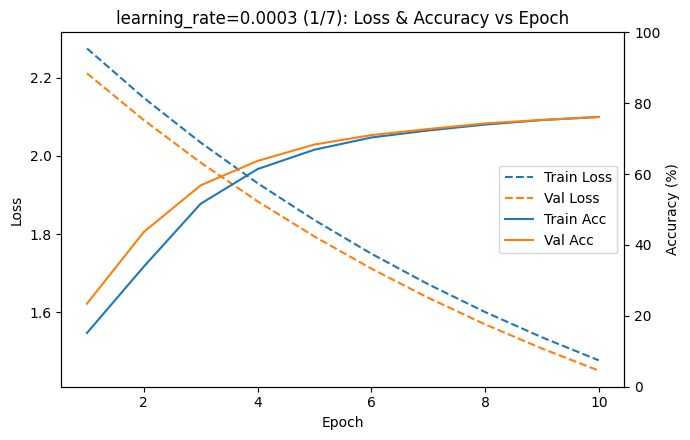


Running learning_rate=0.001 (2/7)
Epoch 1/10 | train: 2.1347, 38.00% | val: 1.9464, 63.65%
Epoch 2/10 | train: 1.7949, 70.83% | val: 1.6591, 74.45%
Epoch 3/10 | train: 1.5484, 76.73% | val: 1.4484, 77.82%
Epoch 4/10 | train: 1.3673, 79.06% | val: 1.2921, 80.08%
Epoch 5/10 | train: 1.2319, 80.36% | val: 1.1735, 81.13%
Epoch 6/10 | train: 1.1281, 81.31% | val: 1.0813, 81.90%
Epoch 7/10 | train: 1.0466, 82.04% | val: 1.0083, 82.32%
Epoch 8/10 | train: 0.9812, 82.58% | val: 0.9487, 82.83%
Epoch 9/10 | train: 0.9275, 83.04% | val: 0.8994, 83.23%
Epoch 10/10 | train: 0.8827, 83.44% | val: 0.8581, 83.45%


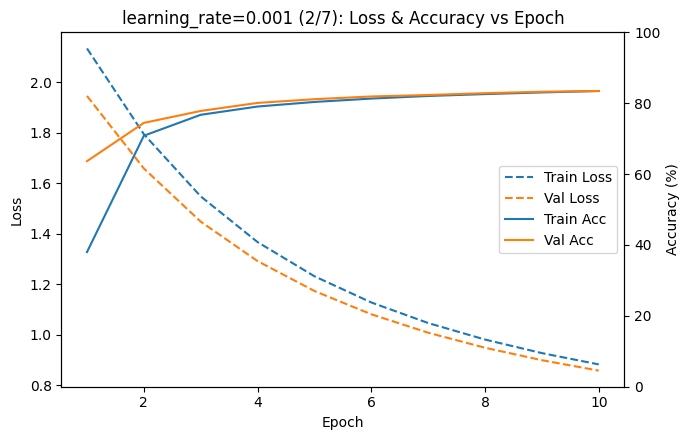


Running learning_rate=0.003 (3/7)
Epoch 1/10 | train: 1.8107, 61.56% | val: 1.4375, 76.03%
Epoch 2/10 | train: 1.2397, 79.03% | val: 1.0797, 80.83%
Epoch 3/10 | train: 0.9866, 82.02% | val: 0.9006, 83.00%
Epoch 4/10 | train: 0.8493, 83.35% | val: 0.7944, 83.97%
Epoch 5/10 | train: 0.7631, 84.31% | val: 0.7242, 84.57%
Epoch 6/10 | train: 0.7035, 84.92% | val: 0.6734, 85.07%
Epoch 7/10 | train: 0.6595, 85.51% | val: 0.6353, 85.32%
Epoch 8/10 | train: 0.6256, 85.85% | val: 0.6052, 85.70%
Epoch 9/10 | train: 0.5984, 86.19% | val: 0.5811, 85.85%
Epoch 10/10 | train: 0.5761, 86.49% | val: 0.5608, 86.12%


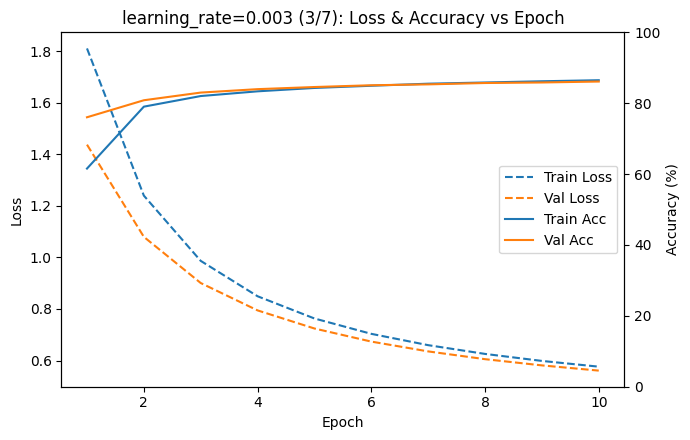


Running learning_rate=0.01 (4/7)
Epoch 1/10 | train: 1.2948, 74.90% | val: 0.8588, 83.13%
Epoch 2/10 | train: 0.7380, 84.46% | val: 0.6454, 85.57%
Epoch 3/10 | train: 0.6035, 86.16% | val: 0.5599, 86.37%
Epoch 4/10 | train: 0.5388, 86.99% | val: 0.5119, 86.87%
Epoch 5/10 | train: 0.4993, 87.58% | val: 0.4804, 87.55%
Epoch 6/10 | train: 0.4722, 87.96% | val: 0.4580, 87.78%
Epoch 7/10 | train: 0.4522, 88.35% | val: 0.4415, 88.10%
Epoch 8/10 | train: 0.4365, 88.58% | val: 0.4274, 88.52%
Epoch 9/10 | train: 0.4239, 88.83% | val: 0.4171, 88.62%
Epoch 10/10 | train: 0.4135, 89.04% | val: 0.4081, 88.77%


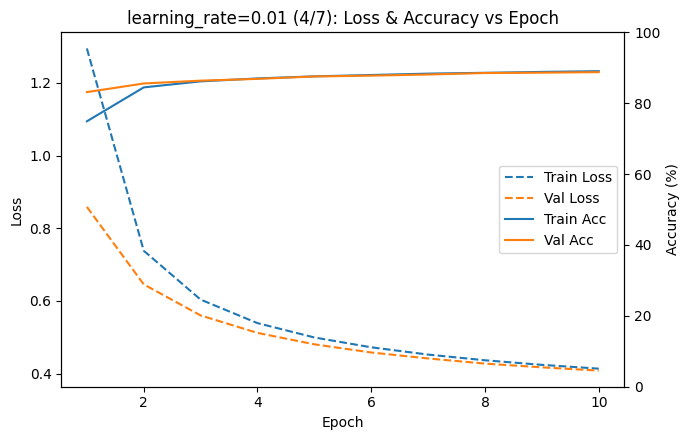


Running learning_rate=0.03 (5/7)
Epoch 1/10 | train: 0.8822, 81.69% | val: 0.5597, 85.93%
Epoch 2/10 | train: 0.5045, 87.43% | val: 0.4589, 87.77%
Epoch 3/10 | train: 0.4384, 88.59% | val: 0.4165, 88.42%
Epoch 4/10 | train: 0.4058, 89.23% | val: 0.3919, 89.25%
Epoch 5/10 | train: 0.3854, 89.62% | val: 0.3773, 89.60%
Epoch 6/10 | train: 0.3711, 89.95% | val: 0.3655, 89.77%
Epoch 7/10 | train: 0.3602, 90.19% | val: 0.3578, 90.10%
Epoch 8/10 | train: 0.3517, 90.41% | val: 0.3501, 90.08%
Epoch 9/10 | train: 0.3447, 90.49% | val: 0.3444, 90.28%
Epoch 10/10 | train: 0.3388, 90.64% | val: 0.3398, 90.45%


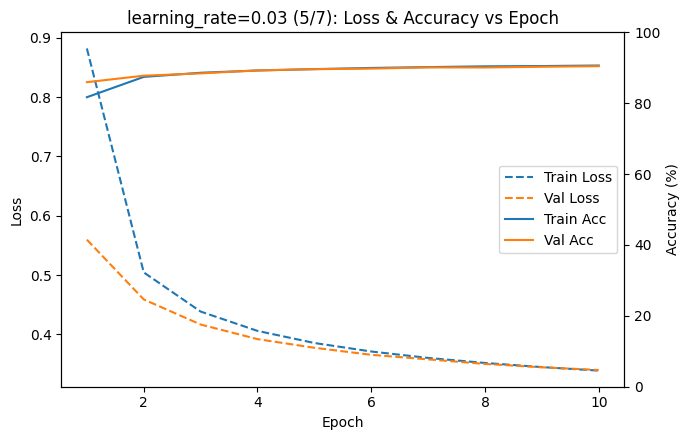


Running learning_rate=0.1 (6/7)
Epoch 1/10 | train: 0.5931, 85.84% | val: 0.4090, 88.52%
Epoch 2/10 | train: 0.3817, 89.57% | val: 0.3599, 89.97%
Epoch 3/10 | train: 0.3483, 90.35% | val: 0.3399, 90.45%
Epoch 4/10 | train: 0.3309, 90.80% | val: 0.3287, 90.73%
Epoch 5/10 | train: 0.3199, 91.07% | val: 0.3202, 90.80%
Epoch 6/10 | train: 0.3118, 91.35% | val: 0.3140, 91.05%
Epoch 7/10 | train: 0.3058, 91.55% | val: 0.3109, 91.30%
Epoch 8/10 | train: 0.3012, 91.62% | val: 0.3075, 91.55%
Epoch 9/10 | train: 0.2972, 91.71% | val: 0.3033, 91.55%
Epoch 10/10 | train: 0.2937, 91.85% | val: 0.3019, 91.58%


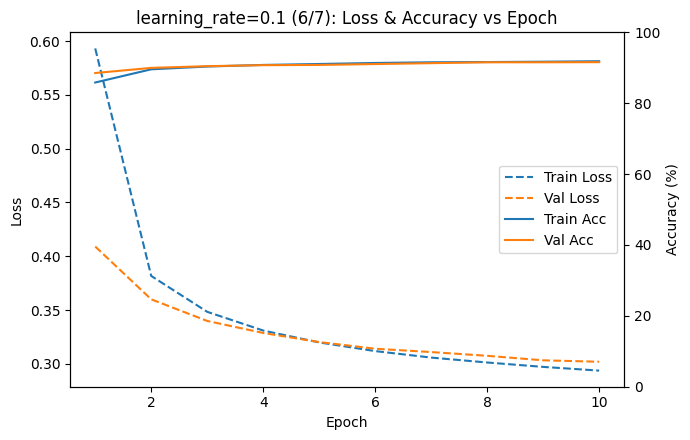


Running learning_rate=0.3 (7/7)
Epoch 1/10 | train: 0.4494, 87.88% | val: 0.3433, 90.35%
Epoch 2/10 | train: 0.3267, 90.77% | val: 0.3179, 91.07%
Epoch 3/10 | train: 0.3068, 91.38% | val: 0.3069, 91.37%
Epoch 4/10 | train: 0.2960, 91.70% | val: 0.3055, 91.33%
Epoch 5/10 | train: 0.2897, 91.89% | val: 0.2978, 91.82%
Epoch 6/10 | train: 0.2845, 92.07% | val: 0.2931, 91.93%
Epoch 7/10 | train: 0.2808, 92.18% | val: 0.2922, 91.77%
Epoch 8/10 | train: 0.2782, 92.20% | val: 0.2912, 91.77%
Epoch 9/10 | train: 0.2751, 92.33% | val: 0.2876, 92.20%
Epoch 10/10 | train: 0.2733, 92.37% | val: 0.2871, 92.02%


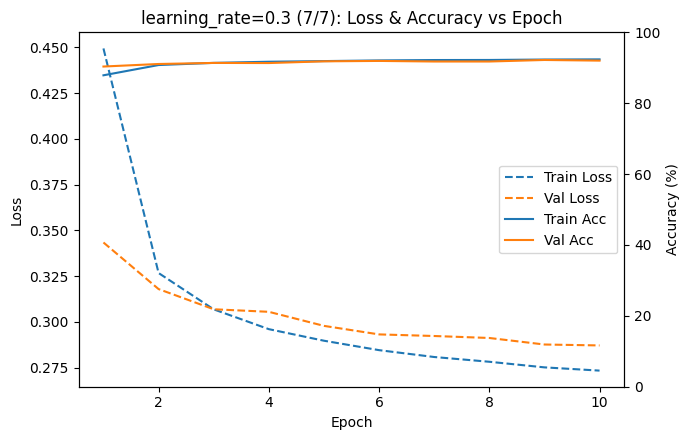


Best learning_rate: 0.3  (acc=92.02%, loss=0.2871)

Running weight_decay=0.0 (1/9)
Epoch 1/10 | train: 2.1197, 38.16% | val: 1.9316, 59.70%
Epoch 2/10 | train: 1.7845, 68.19% | val: 1.6510, 71.85%
Epoch 3/10 | train: 1.5436, 74.82% | val: 1.4451, 76.27%
Epoch 4/10 | train: 1.3663, 77.56% | val: 1.2919, 78.32%
Epoch 5/10 | train: 1.2332, 79.36% | val: 1.1753, 79.70%
Epoch 6/10 | train: 1.1308, 80.46% | val: 1.0843, 80.87%
Epoch 7/10 | train: 1.0501, 81.31% | val: 1.0118, 81.57%
Epoch 8/10 | train: 0.9851, 81.94% | val: 0.9528, 82.17%
Epoch 9/10 | train: 0.9317, 82.49% | val: 0.9038, 82.68%
Epoch 10/10 | train: 0.8870, 82.96% | val: 0.8626, 83.02%


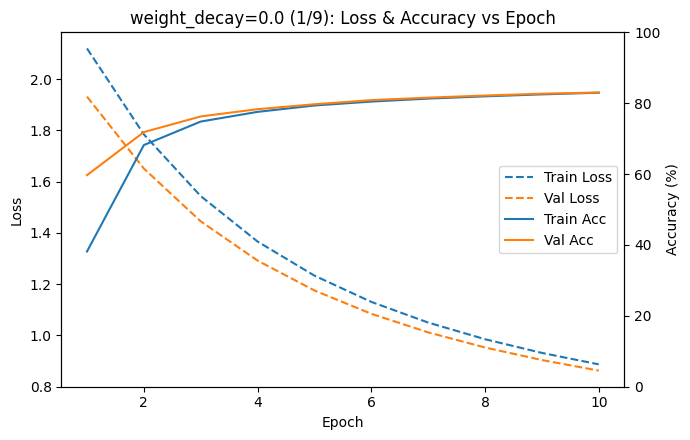


Running weight_decay=1e-06 (2/9)
Epoch 1/10 | train: 2.1013, 40.51% | val: 1.9196, 63.05%
Epoch 2/10 | train: 1.7730, 70.52% | val: 1.6404, 73.58%
Epoch 3/10 | train: 1.5335, 75.81% | val: 1.4352, 76.68%
Epoch 4/10 | train: 1.3570, 78.15% | val: 1.2827, 78.40%
Epoch 5/10 | train: 1.2244, 79.67% | val: 1.1667, 79.93%
Epoch 6/10 | train: 1.1226, 80.64% | val: 1.0762, 80.77%
Epoch 7/10 | train: 1.0426, 81.47% | val: 1.0042, 81.63%
Epoch 8/10 | train: 0.9781, 82.17% | val: 0.9458, 82.25%
Epoch 9/10 | train: 0.9252, 82.66% | val: 0.8973, 82.78%
Epoch 10/10 | train: 0.8810, 83.11% | val: 0.8564, 83.13%


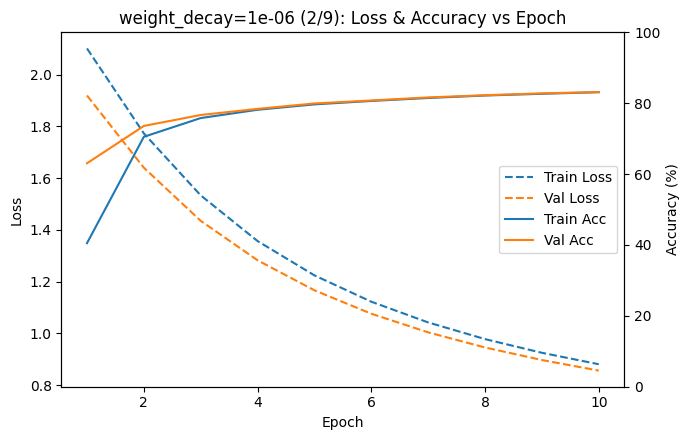


Running weight_decay=3e-06 (3/9)
Epoch 1/10 | train: 2.0846, 42.54% | val: 1.9047, 64.48%
Epoch 2/10 | train: 1.7585, 70.76% | val: 1.6295, 72.82%
Epoch 3/10 | train: 1.5225, 75.23% | val: 1.4276, 76.32%
Epoch 4/10 | train: 1.3487, 77.53% | val: 1.2774, 78.33%
Epoch 5/10 | train: 1.2183, 79.19% | val: 1.1632, 79.90%
Epoch 6/10 | train: 1.1181, 80.37% | val: 1.0741, 80.72%
Epoch 7/10 | train: 1.0391, 81.27% | val: 1.0029, 81.55%
Epoch 8/10 | train: 0.9754, 81.94% | val: 0.9449, 82.30%
Epoch 9/10 | train: 0.9230, 82.51% | val: 0.8969, 82.62%
Epoch 10/10 | train: 0.8792, 83.01% | val: 0.8562, 83.00%


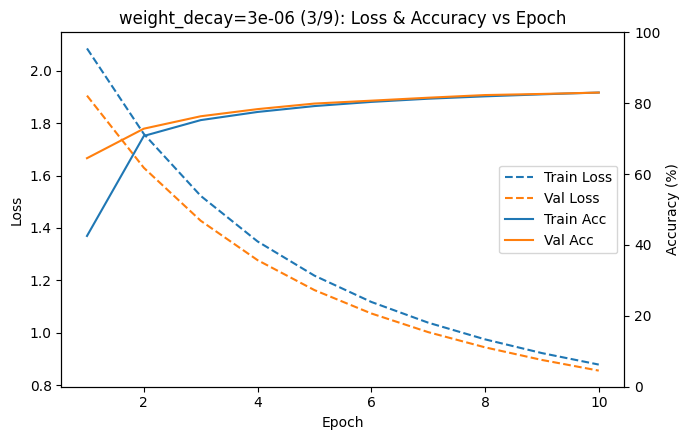


Running weight_decay=1e-05 (4/9)
Epoch 1/10 | train: 2.1457, 32.53% | val: 1.9568, 58.70%
Epoch 2/10 | train: 1.8056, 67.47% | val: 1.6679, 71.67%
Epoch 3/10 | train: 1.5581, 74.23% | val: 1.4565, 75.48%
Epoch 4/10 | train: 1.3763, 76.94% | val: 1.2998, 78.15%
Epoch 5/10 | train: 1.2402, 78.98% | val: 1.1809, 79.80%
Epoch 6/10 | train: 1.1358, 80.25% | val: 1.0885, 81.00%
Epoch 7/10 | train: 1.0538, 81.13% | val: 1.0147, 81.93%
Epoch 8/10 | train: 0.9879, 81.83% | val: 0.9549, 82.52%
Epoch 9/10 | train: 0.9338, 82.47% | val: 0.9055, 82.92%
Epoch 10/10 | train: 0.8886, 82.88% | val: 0.8638, 83.27%


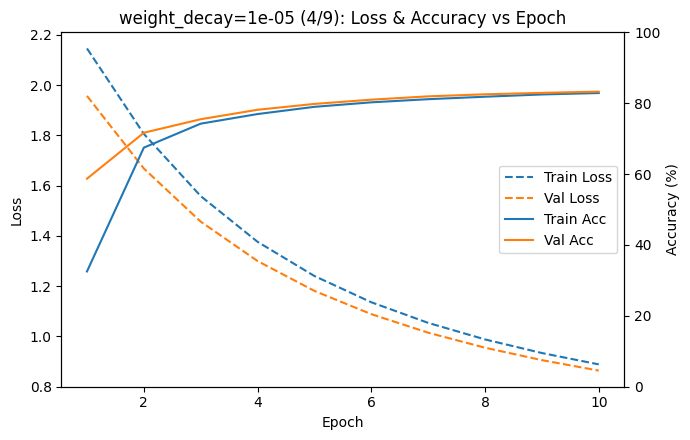


Running weight_decay=3e-05 (5/9)
Epoch 1/10 | train: 2.0868, 42.11% | val: 1.9069, 62.58%
Epoch 2/10 | train: 1.7613, 68.24% | val: 1.6316, 72.13%
Epoch 3/10 | train: 1.5254, 74.56% | val: 1.4297, 75.85%
Epoch 4/10 | train: 1.3518, 77.27% | val: 1.2795, 78.08%
Epoch 5/10 | train: 1.2215, 78.96% | val: 1.1652, 79.65%
Epoch 6/10 | train: 1.1213, 80.26% | val: 1.0761, 80.52%
Epoch 7/10 | train: 1.0423, 81.10% | val: 1.0049, 81.57%
Epoch 8/10 | train: 0.9786, 81.80% | val: 0.9468, 82.37%
Epoch 9/10 | train: 0.9262, 82.42% | val: 0.8987, 82.78%
Epoch 10/10 | train: 0.8823, 82.90% | val: 0.8580, 83.00%


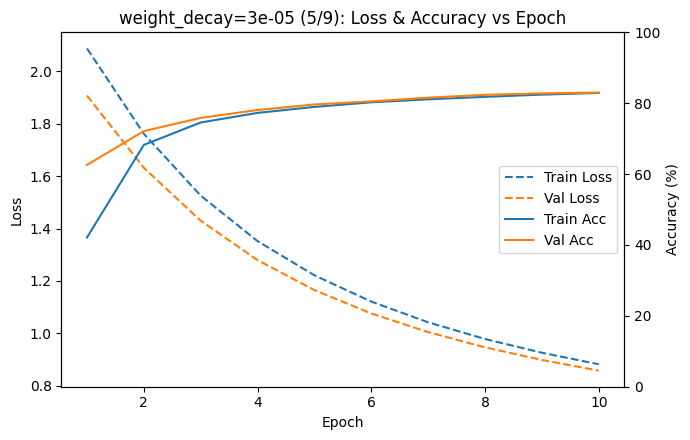


Running weight_decay=0.0001 (6/9)
Epoch 1/10 | train: 2.1283, 37.91% | val: 1.9395, 61.43%
Epoch 2/10 | train: 1.7910, 69.01% | val: 1.6544, 73.17%
Epoch 3/10 | train: 1.5462, 75.34% | val: 1.4453, 77.03%
Epoch 4/10 | train: 1.3662, 78.05% | val: 1.2902, 79.00%
Epoch 5/10 | train: 1.2315, 79.53% | val: 1.1723, 80.33%
Epoch 6/10 | train: 1.1283, 80.67% | val: 1.0809, 81.33%
Epoch 7/10 | train: 1.0472, 81.40% | val: 1.0080, 82.08%
Epoch 8/10 | train: 0.9819, 82.02% | val: 0.9488, 82.73%
Epoch 9/10 | train: 0.9284, 82.58% | val: 0.9000, 83.05%
Epoch 10/10 | train: 0.8838, 82.98% | val: 0.8587, 83.37%


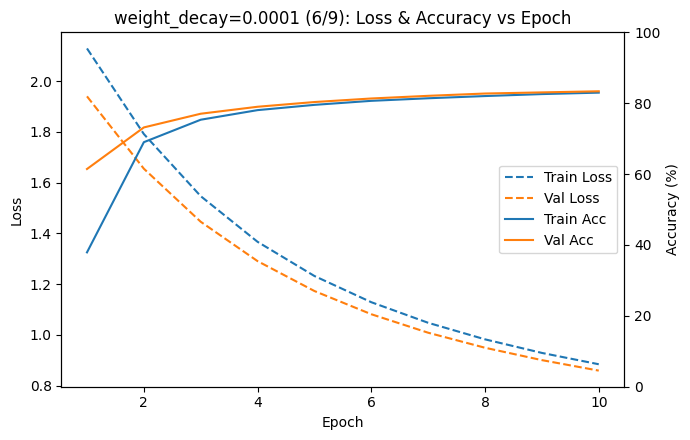


Running weight_decay=0.0003 (7/9)
Epoch 1/10 | train: 2.1206, 38.33% | val: 1.9344, 60.62%
Epoch 2/10 | train: 1.7862, 68.45% | val: 1.6517, 72.73%
Epoch 3/10 | train: 1.5442, 74.86% | val: 1.4445, 76.50%
Epoch 4/10 | train: 1.3658, 77.51% | val: 1.2905, 78.25%
Epoch 5/10 | train: 1.2321, 79.12% | val: 1.1735, 79.60%
Epoch 6/10 | train: 1.1293, 80.19% | val: 1.0823, 80.88%
Epoch 7/10 | train: 1.0485, 81.10% | val: 1.0097, 81.60%
Epoch 8/10 | train: 0.9835, 81.76% | val: 0.9506, 82.37%
Epoch 9/10 | train: 0.9301, 82.33% | val: 0.9017, 82.80%
Epoch 10/10 | train: 0.8855, 82.76% | val: 0.8605, 83.05%


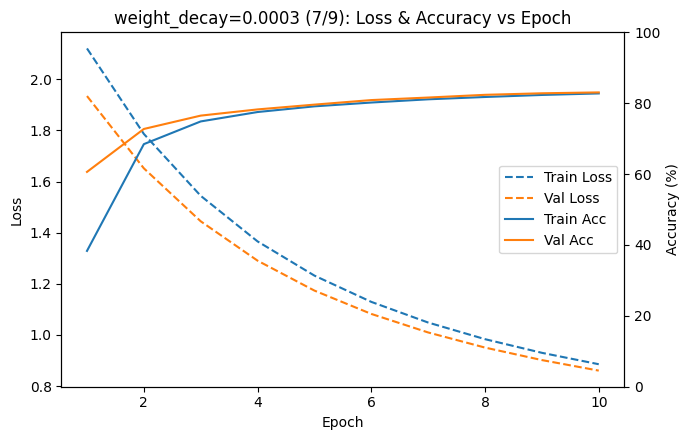


Running weight_decay=0.001 (8/9)
Epoch 1/10 | train: 2.0895, 43.21% | val: 1.9043, 66.13%
Epoch 2/10 | train: 1.7610, 71.11% | val: 1.6283, 74.02%
Epoch 3/10 | train: 1.5234, 75.49% | val: 1.4259, 77.10%
Epoch 4/10 | train: 1.3488, 77.97% | val: 1.2753, 78.83%
Epoch 5/10 | train: 1.2180, 79.74% | val: 1.1611, 80.08%
Epoch 6/10 | train: 1.1176, 80.82% | val: 1.0722, 81.12%
Epoch 7/10 | train: 1.0386, 81.61% | val: 1.0013, 81.95%
Epoch 8/10 | train: 0.9751, 82.21% | val: 0.9436, 82.52%
Epoch 9/10 | train: 0.9229, 82.76% | val: 0.8958, 82.95%
Epoch 10/10 | train: 0.8793, 83.15% | val: 0.8556, 83.23%


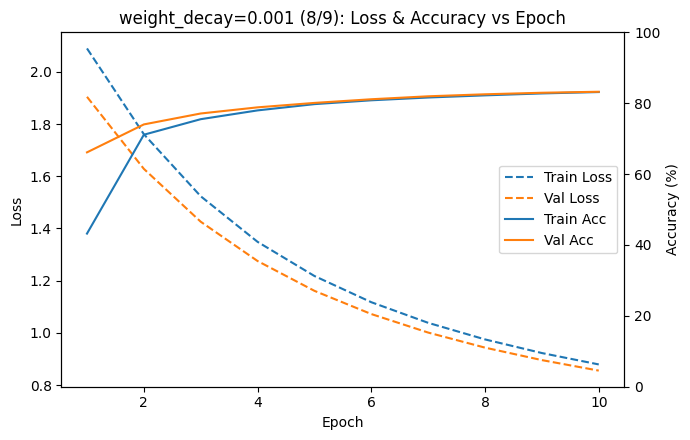


Running weight_decay=0.003 (9/9)
Epoch 1/10 | train: 2.1225, 40.14% | val: 1.9371, 64.38%
Epoch 2/10 | train: 1.7870, 70.05% | val: 1.6542, 71.75%
Epoch 3/10 | train: 1.5445, 74.85% | val: 1.4472, 75.48%
Epoch 4/10 | train: 1.3664, 77.38% | val: 1.2931, 77.87%
Epoch 5/10 | train: 1.2330, 78.98% | val: 1.1762, 79.52%
Epoch 6/10 | train: 1.1306, 80.28% | val: 1.0852, 80.55%
Epoch 7/10 | train: 1.0501, 81.15% | val: 1.0127, 81.30%
Epoch 8/10 | train: 0.9853, 81.84% | val: 0.9537, 82.00%
Epoch 9/10 | train: 0.9321, 82.44% | val: 0.9048, 82.80%
Epoch 10/10 | train: 0.8877, 82.97% | val: 0.8637, 83.07%


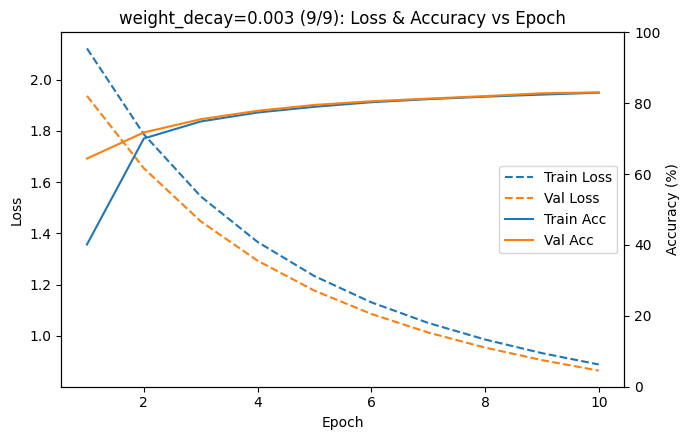


Best weight_decay: 0.0001  (acc=83.37%, loss=0.8587)

Running batch_size=16 (1/6)
Epoch 1/10 | train: 1.3847, 73.61% | val: 0.9447, 82.43%
Epoch 2/10 | train: 0.8076, 83.75% | val: 0.7037, 84.68%
Epoch 3/10 | train: 0.6539, 85.53% | val: 0.6039, 85.88%
Epoch 4/10 | train: 0.5793, 86.47% | val: 0.5478, 86.45%
Epoch 5/10 | train: 0.5338, 87.09% | val: 0.5113, 86.85%
Epoch 6/10 | train: 0.5026, 87.56% | val: 0.4854, 87.25%
Epoch 7/10 | train: 0.4795, 87.91% | val: 0.4653, 87.70%
Epoch 8/10 | train: 0.4617, 88.20% | val: 0.4502, 87.90%
Epoch 9/10 | train: 0.4473, 88.44% | val: 0.4375, 88.22%
Epoch 10/10 | train: 0.4354, 88.67% | val: 0.4270, 88.38%


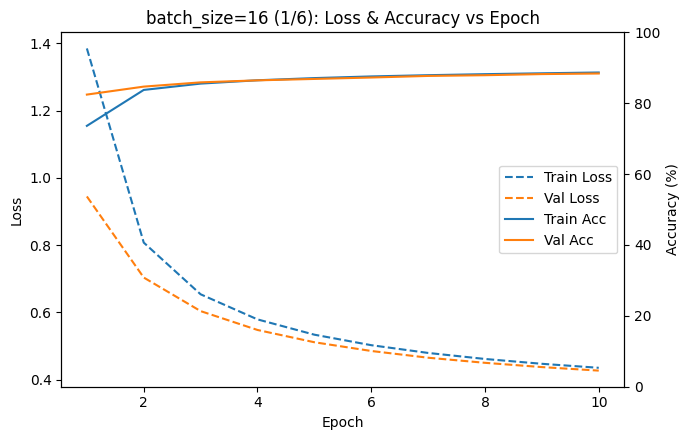


Running batch_size=32 (2/6)
Epoch 1/10 | train: 1.6881, 66.94% | val: 1.2778, 78.68%
Epoch 2/10 | train: 1.0898, 80.81% | val: 0.9439, 82.35%
Epoch 3/10 | train: 0.8649, 83.06% | val: 0.7914, 83.63%
Epoch 4/10 | train: 0.7493, 84.29% | val: 0.7031, 84.53%
Epoch 5/10 | train: 0.6781, 85.18% | val: 0.6452, 85.12%
Epoch 6/10 | train: 0.6291, 85.80% | val: 0.6036, 85.70%
Epoch 7/10 | train: 0.5930, 86.27% | val: 0.5725, 85.92%
Epoch 8/10 | train: 0.5652, 86.64% | val: 0.5479, 86.30%
Epoch 9/10 | train: 0.5428, 86.95% | val: 0.5279, 86.72%
Epoch 10/10 | train: 0.5245, 87.13% | val: 0.5114, 86.77%


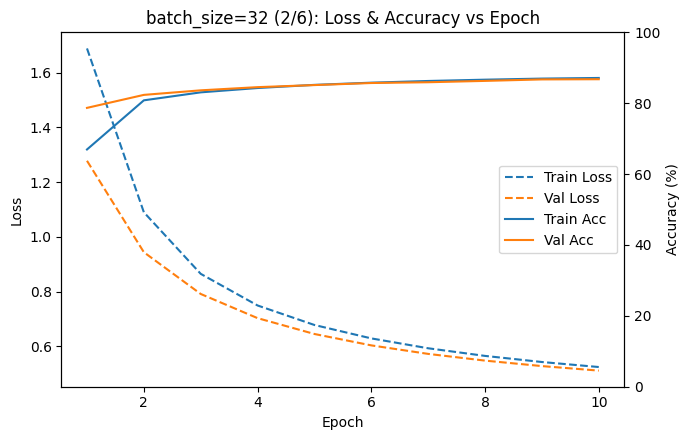


Running batch_size=64 (3/6)
Epoch 1/10 | train: 1.9291, 57.31% | val: 1.6303, 72.72%
Epoch 2/10 | train: 1.4379, 76.13% | val: 1.2770, 78.42%
Epoch 3/10 | train: 1.1702, 79.61% | val: 1.0742, 80.92%
Epoch 4/10 | train: 1.0094, 81.38% | val: 0.9456, 82.30%
Epoch 5/10 | train: 0.9035, 82.46% | val: 0.8569, 83.23%
Epoch 6/10 | train: 0.8284, 83.49% | val: 0.7928, 83.58%
Epoch 7/10 | train: 0.7723, 84.02% | val: 0.7432, 84.02%
Epoch 8/10 | train: 0.7286, 84.53% | val: 0.7041, 84.55%
Epoch 9/10 | train: 0.6934, 85.00% | val: 0.6724, 84.90%
Epoch 10/10 | train: 0.6645, 85.33% | val: 0.6457, 85.18%


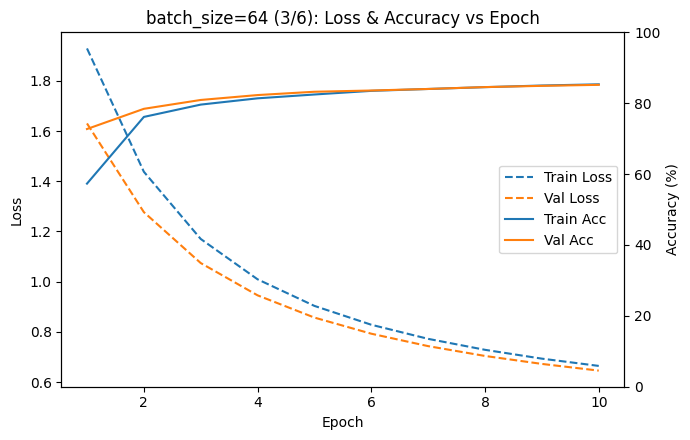


Running batch_size=128 (4/6)
Epoch 1/10 | train: 2.1237, 36.96% | val: 1.9415, 60.70%
Epoch 2/10 | train: 1.7907, 68.22% | val: 1.6568, 71.98%
Epoch 3/10 | train: 1.5467, 74.54% | val: 1.4477, 75.97%
Epoch 4/10 | train: 1.3671, 77.36% | val: 1.2924, 78.08%
Epoch 5/10 | train: 1.2326, 79.08% | val: 1.1744, 79.60%
Epoch 6/10 | train: 1.1294, 80.33% | val: 1.0829, 80.75%
Epoch 7/10 | train: 1.0483, 81.19% | val: 1.0099, 81.42%
Epoch 8/10 | train: 0.9831, 81.83% | val: 0.9506, 82.32%
Epoch 9/10 | train: 0.9296, 82.42% | val: 0.9015, 82.75%
Epoch 10/10 | train: 0.8849, 82.83% | val: 0.8601, 83.25%


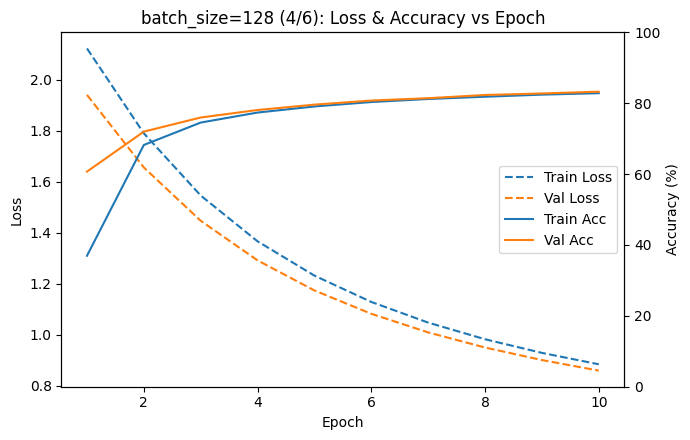


Running batch_size=256 (5/6)
Epoch 1/10 | train: 2.2001, 24.87% | val: 2.0971, 42.87%
Epoch 2/10 | train: 2.0072, 55.40% | val: 1.9200, 63.22%
Epoch 3/10 | train: 1.8437, 67.01% | val: 1.7690, 69.83%
Epoch 4/10 | train: 1.7041, 71.82% | val: 1.6400, 72.62%
Epoch 5/10 | train: 1.5850, 74.33% | val: 1.5297, 74.70%
Epoch 6/10 | train: 1.4830, 75.88% | val: 1.4349, 76.37%
Epoch 7/10 | train: 1.3954, 77.19% | val: 1.3534, 77.58%
Epoch 8/10 | train: 1.3198, 78.17% | val: 1.2826, 78.65%
Epoch 9/10 | train: 1.2541, 78.90% | val: 1.2209, 79.38%
Epoch 10/10 | train: 1.1967, 79.63% | val: 1.1670, 80.12%


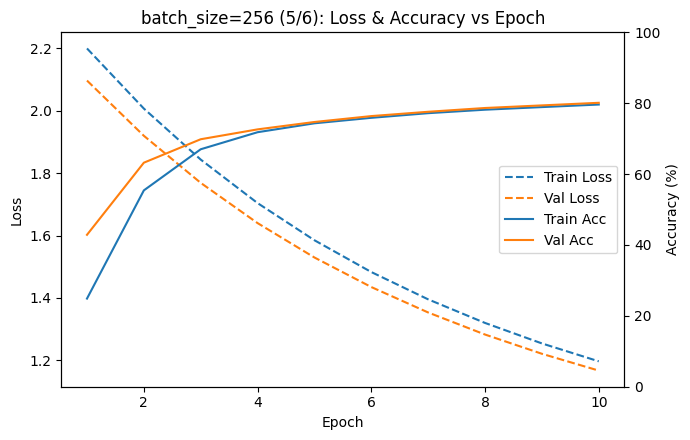


Running batch_size=512 (6/6)
Epoch 1/10 | train: 2.2535, 17.90% | val: 2.1985, 28.17%
Epoch 2/10 | train: 2.1486, 38.98% | val: 2.0987, 48.67%
Epoch 3/10 | train: 2.0525, 54.18% | val: 2.0067, 59.05%
Epoch 4/10 | train: 1.9639, 61.84% | val: 1.9217, 65.08%
Epoch 5/10 | train: 1.8821, 66.29% | val: 1.8432, 67.82%
Epoch 6/10 | train: 1.8066, 69.04% | val: 1.7706, 69.85%
Epoch 7/10 | train: 1.7368, 70.95% | val: 1.7034, 71.37%
Epoch 8/10 | train: 1.6723, 72.41% | val: 1.6414, 72.80%
Epoch 9/10 | train: 1.6128, 73.45% | val: 1.5839, 73.77%
Epoch 10/10 | train: 1.5576, 74.43% | val: 1.5307, 74.70%


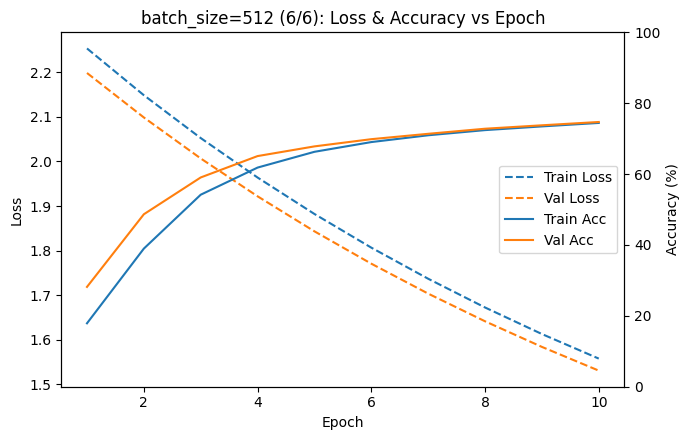


Best batch_size: 16  (acc=88.38%, loss=0.4270)


In [7]:
#What's being tuned?
best_LR = auto_adjuster("learning_rate", LR_set, base_config)
best_L2 = auto_adjuster("weight_decay", L2_set, base_config)
best_batch = auto_adjuster("batch_size", batch_set, base_config)

## Final Training/Evaluation

The next couple cells will complete this notebook and finish the optimized linear classifier. The model trained from base configuration and "best" configuration will be compared, both in final training and final evaluation. 

Epoch 1/10 | train: 2.1608, 34.63% | val: 1.9668, 61.75%
Epoch 2/10 | train: 1.8130, 69.07% | val: 1.6744, 72.52%
Epoch 3/10 | train: 1.5622, 74.80% | val: 1.4604, 76.40%
Epoch 4/10 | train: 1.3784, 77.33% | val: 1.3021, 78.20%
Epoch 5/10 | train: 1.2412, 79.07% | val: 1.1823, 79.52%
Epoch 6/10 | train: 1.1363, 80.30% | val: 1.0893, 80.60%
Epoch 7/10 | train: 1.0540, 81.14% | val: 1.0153, 81.42%
Epoch 8/10 | train: 0.9879, 81.86% | val: 0.9556, 82.08%
Epoch 9/10 | train: 0.9338, 82.39% | val: 0.9059, 82.65%
Epoch 10/10 | train: 0.8886, 82.88% | val: 0.8643, 83.18%


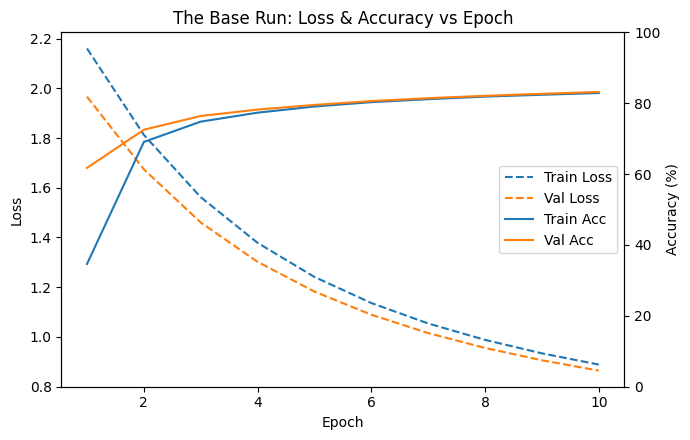


Base (no tuning): acc=83.18%, loss=0.8643

Epoch 1/10 | train: 0.3810, 88.93% | val: 0.3609, 89.43%
Epoch 2/10 | train: 0.3268, 90.67% | val: 0.3260, 90.82%
Epoch 3/10 | train: 0.3189, 90.93% | val: 0.3432, 90.50%
Epoch 4/10 | train: 0.3126, 91.19% | val: 0.3146, 91.30%
Epoch 5/10 | train: 0.3079, 91.26% | val: 0.3477, 90.23%
Epoch 6/10 | train: 0.3051, 91.38% | val: 0.3217, 90.93%
Epoch 7/10 | train: 0.3027, 91.45% | val: 0.3206, 91.25%
Epoch 8/10 | train: 0.3026, 91.45% | val: 0.3410, 89.95%
Epoch 9/10 | train: 0.3021, 91.43% | val: 0.3332, 90.97%
Epoch 10/10 | train: 0.3020, 91.44% | val: 0.3344, 90.37%


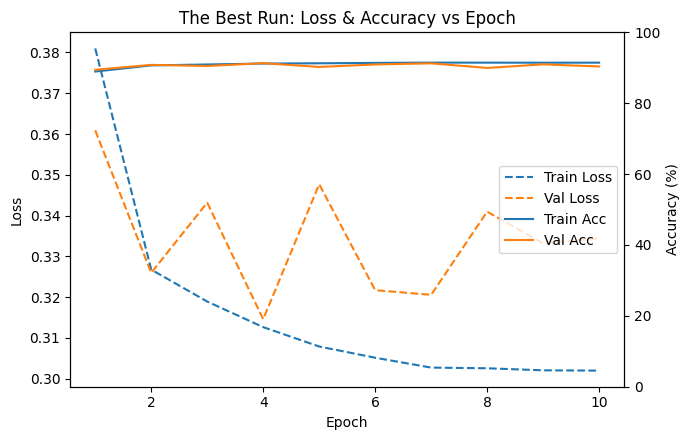

Tuned: acc=90.37%, loss=0.3344


In [8]:
#Compare the two

best_config = {
    'num_epochs': 10,
    'learning_rate': best_LR,
    'weight_decay': best_L2,
    'batch_size': best_batch,
}

base_run_name = "The Base Run"
base_acc, base_loss, base_model = trainLoopAndPlot(base_config, run_name=base_run_name, return_model=True)

print(f"\nBase (no tuning): acc={base_acc:.2f}%, loss={base_loss:.4f}\n")

best_run_name = "The Best Run"
best_acc, best_loss, best_model = trainLoopAndPlot(best_config, run_name=best_run_name, return_model=True)

print(f"Tuned: acc={best_acc:.2f}%, loss={best_loss:.4f}")

Base Model Test Accuracy: 83.98%
Best Model Test Accuracy: 90.74%


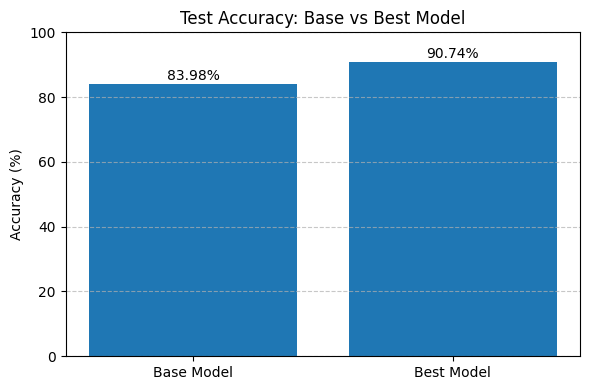

In [9]:
#Evaluation side by side
def the_great_evaluator(model, test_dataset, batch_size, label="Model"):
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    model.eval()

    correct = 0
    total = 0

    #The real deal
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)              
            predicted = logits.argmax(dim=1)    
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = 100.0 * correct / total
    print(f"{label} Test Accuracy: {test_accuracy:.2f}%")
    return test_accuracy


#Run evaluations 
base_test_acc = the_great_evaluator(
    base_model,
    test_dataset,
    batch_size=base_config["batch_size"],
    label="Base Model"
)

best_test_acc = the_great_evaluator(
    best_model,
    test_dataset,
    batch_size=best_config["batch_size"],
    label="Best Model"
)


#Plot
labels = ["Base Model", "Best Model"]
accuracies = [base_test_acc, best_test_acc]
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, accuracies)

for bar, acc in zip(bars, accuracies):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 0.5,
        f"{acc:.2f}%",
        ha="center",
        va="bottom",
    )

plt.title("Test Accuracy: Base vs Best Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## The End

This model is very simple and only understands the image as a flat vector literally assigning a weight to every pixel so it's highly susceptible to being confused by changes in the images. This could be improved by understanding spatial relationships which is where a Convolutional Neural Network would come into play. 

For now, see the cell below to see its predictions:

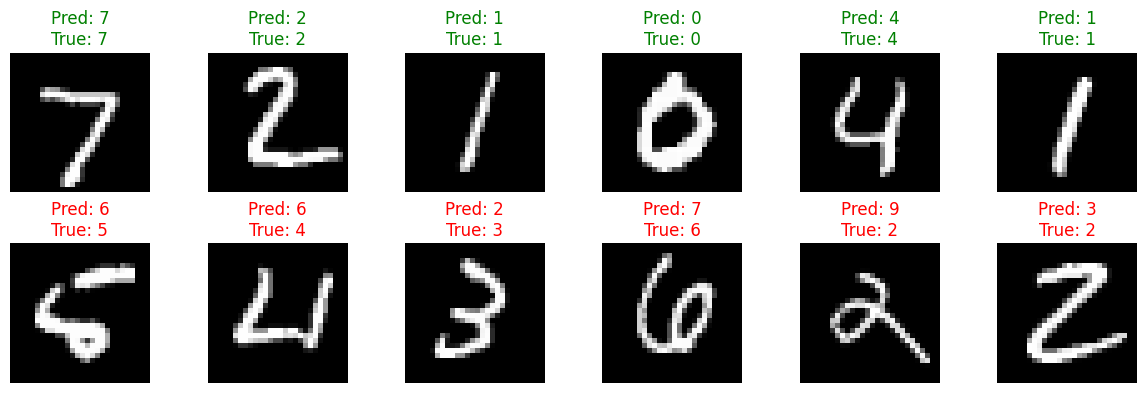

In [10]:
def show_predictions(model, dataset, batch_size=128, num_examples=6):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    correct_examples = []
    wrong_examples = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)

            for img, pred, true in zip(images, preds, labels):

                if pred == true and len(correct_examples) < num_examples:
                    correct_examples.append((img.cpu(), pred.item(), true.item()))

                if pred != true and len(wrong_examples) < num_examples:
                    wrong_examples.append((img.cpu(), pred.item(), true.item()))

                if len(correct_examples) >= num_examples and len(wrong_examples) >= num_examples:
                    break
            if len(correct_examples) >= num_examples and len(wrong_examples) >= num_examples:
                break

    #Plot results
    fig, axes = plt.subplots(2, num_examples, figsize=(2*num_examples, 4))

    for i in range(num_examples):
        
        #Correct row
        img, pred, true = correct_examples[i]
        axes[0, i].imshow(img.squeeze(), cmap="gray")
        axes[0, i].set_title(f"Pred: {pred}\nTrue: {true}", color="green")
        axes[0, i].axis("off")

        #Wrong row
        img, pred, true = wrong_examples[i]
        axes[1, i].imshow(img.squeeze(), cmap="gray")
        axes[1, i].set_title(f"Pred: {pred}\nTrue: {true}", color="red")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Correct", fontsize=12)
    axes[1, 0].set_ylabel("Wrong", fontsize=12)

    plt.tight_layout()
    plt.show()

#Get predictions
show_predictions(best_model, test_dataset)

For more analysis of its predictions, here is a confusion matrix:

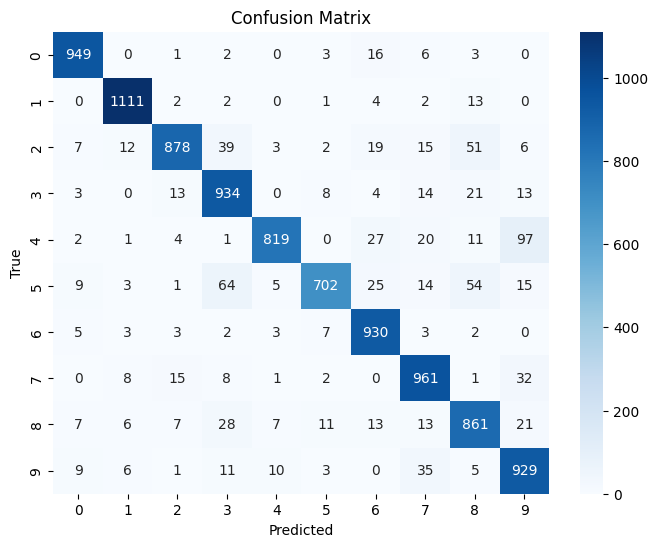

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=256, shuffle=False)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu()

            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

#Get confusion matrix
plot_confusion_matrix(best_model, test_dataset)